# Data Analysis Scrap Sheet

In [2]:
%run helperFunctions.ipynb
import numpy as np
from scipy.spatial import cKDTree
from sklearn.cluster import KMeans


read: ./data/faulty\Circuit_Scenario1_batery_1_broken_res.csv
read: ./data/faulty\Circuit_Scenario1_switch1_broken_res.csv
read: ./data/faulty\Circuit_Scenario2_battery2_broken_res.csv
read: ./data/faulty\Circuit_Scenario2_battery2_empty_res.csv
read: ./data/faulty\Circuit_Scenario2_switch_2_broken_res.csv
read: ./data/faulty\Circuit_Scenario3_battery_1_empty_res.csv
read: ./data/faulty\Circuit_Scenario3_switch_1_broken_res.csv
read: ./data/faulty\Circuit_Scenario4_battery_1_broken_res.csv
read: ./data/faulty\Circuit_Scenario4_battery_1_empty_res.csv
read: ./data/faulty\Circuit_Scenario4_switch_1_broken_res.csv
read: ./data/faultless\Circuit_Scenario1_res.csv
read: ./data/faultless\Circuit_Scenario2_res.csv
read: ./data/faultless\Circuit_Scenario3_res.csv
read: ./data/faultless\Circuit_Scenario4_res.csv


In [3]:
faulty = getFaultyData()[["circ1.r_load.v", "circ1.r_load.i"]].astype(float).values
faultless = getFaultlessData()[["circ1.r_load.v", "circ1.r_load.i"]].astype(float).values
training = getTrainingDataResistance()[["circ1.r_load.v", "circ1.r_load.i"]].astype(float).values

read: ./data/faulty\Circuit_Scenario1_batery_1_broken_res.csv
read: ./data/faulty\Circuit_Scenario1_switch1_broken_res.csv
read: ./data/faulty\Circuit_Scenario2_battery2_broken_res.csv
read: ./data/faulty\Circuit_Scenario2_battery2_empty_res.csv
read: ./data/faulty\Circuit_Scenario2_switch_2_broken_res.csv
read: ./data/faulty\Circuit_Scenario3_battery_1_empty_res.csv
read: ./data/faulty\Circuit_Scenario3_switch_1_broken_res.csv
read: ./data/faulty\Circuit_Scenario4_battery_1_broken_res.csv
read: ./data/faulty\Circuit_Scenario4_battery_1_empty_res.csv
read: ./data/faulty\Circuit_Scenario4_switch_1_broken_res.csv
read: ./data/faultless\Circuit_Scenario1_res.csv
read: ./data/faultless\Circuit_Scenario2_res.csv
read: ./data/faultless\Circuit_Scenario3_res.csv
read: ./data/faultless\Circuit_Scenario4_res.csv
read: ./data/training/Circuit_ScenarioDataGeneration_Restistance_res.csv


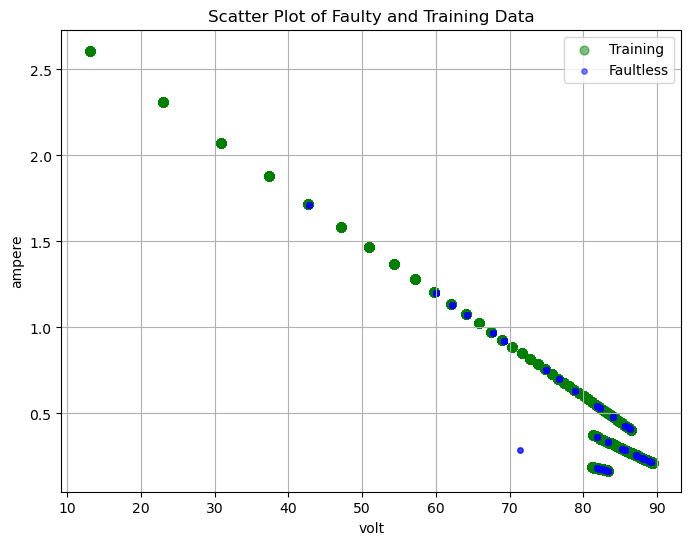

In [4]:
plt.figure(figsize=(8, 6))

plt.scatter(training[:, 0], training[:, 1], s=40, color='green', alpha=0.5, label='Training')
plt.scatter(faultless[:, 0], faultless[:, 1], s=15, color='blue', alpha=0.5, label='Faultless')
#plt.scatter(faulty[:, 0], faulty[:, 1], s=15, color='red', alpha=0.5, label='Faulty')
plt.xlabel('volt')
plt.ylabel('ampere')
plt.title('Scatter Plot of Faulty and Training Data')
plt.legend()
plt.grid(True)
plt.savefig('scatter_plot_all_training_data.png', dpi=300, bbox_inches='tight')
plt.show()


In [84]:

# Combine all arrays to identify unique rows
combined = np.vstack((faulty, faultless, training))
unique_rows, indices = np.unique(combined, axis=0, return_inverse=True)

# Split back into separate arrays
num_faulty = len(faulty)
num_faultless = len(faultless)

unique_faulty = unique_rows[indices[:num_faulty]]
unique_faultless = unique_rows[indices[num_faulty:num_faulty + num_faultless]]
unique_training = unique_rows[indices[num_faulty + num_faultless:]]

# Reassign unique arrays
faulty = unique_faulty
faultless = unique_faultless
training = unique_training

print("Faulty:", faulty)
print("Faultless:", faultless)
print("Training:", training)

Faulty: [[-0.00000000e+00  4.00011309e-19]
 [-0.00000000e+00  4.00011309e-19]
 [-0.00000000e+00  4.00011309e-19]
 ...
 [ 7.72727308e+01  2.27272738e-01]
 [ 7.72727308e+01  2.27272738e-01]
 [ 7.72727308e+01  2.27272738e-01]]
Faultless: [[83.33333611  0.16666667]
 [83.33333611  0.16666667]
 [83.33333611  0.16666667]
 ...
 [87.17948774  0.25641026]
 [87.17948774  0.25641026]
 [87.17948774  0.25641026]]
Training: [[13.04347826  2.60869565]
 [13.04347826  2.60869565]
 [13.04347826  2.60869565]
 ...
 [83.33333611  0.16666667]
 [83.33333611  0.16666667]
 [83.33333611  0.16666667]]


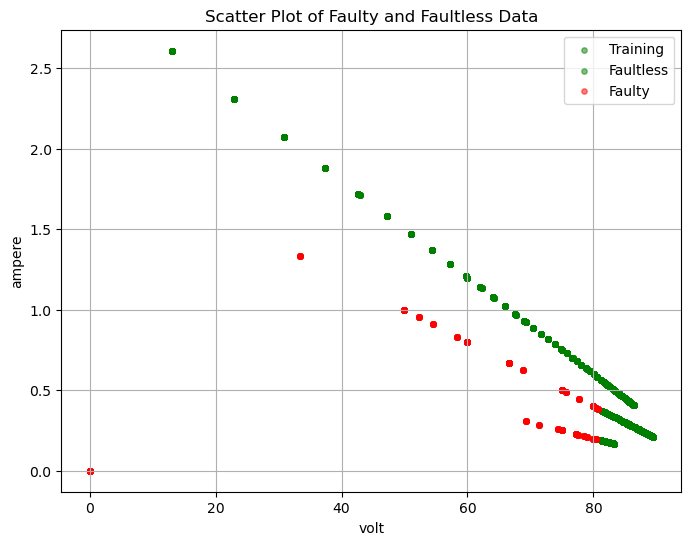

In [55]:
plt.figure(figsize=(8, 6))

plt.scatter(unique_training[:, 0], unique_training[:, 1], s=15, color='green', alpha=0.5, label='Training')
plt.scatter(unique_faultless[:, 0], unique_faultless[:, 1], s=15, color='green', alpha=0.5, label='Faultless')
plt.scatter(unique_faulty[:, 0], unique_faulty[:, 1], s=15, color='red', alpha=0.5, label='Faulty')
plt.xlabel('volt')
plt.ylabel('ampere')
plt.title('Scatter Plot of Faulty and Faultless Data')
plt.legend()
plt.grid(True)
plt.show()

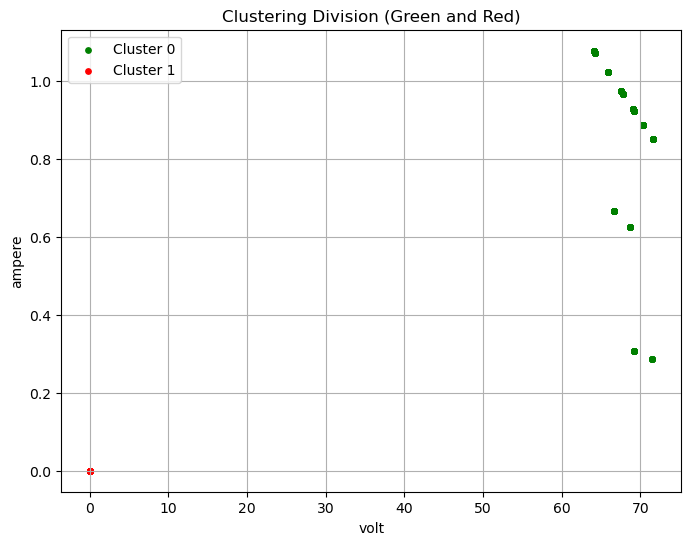

In [78]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Combine the data (faulty, faultless, training)
combined_data = np.vstack((faulty, faultless, training))

# Apply k-means clustering with k=2
kmeans = KMeans(n_clusters=8, random_state=42)
kmeans.fit(combined_data)

# Get cluster labels
cluster_labels = kmeans.labels_

# Split the combined data into clusters
cluster_0 = combined_data[cluster_labels == 0]
cluster_1 = combined_data[cluster_labels == 1]

# Visualize the clusters
plt.figure(figsize=(8, 6))
plt.scatter(cluster_0[:, 0], cluster_0[:, 1], s=15, color='green', label='Cluster 0')
plt.scatter(cluster_1[:, 0], cluster_1[:, 1], s=15, color='red', label='Cluster 1')
plt.xlabel('volt')
plt.ylabel('ampere')
plt.title('Clustering Division (Green and Red)')
plt.legend()
plt.grid(True)
plt.show()